# Online Retail Sales Analysis

## Project Overview

This project analyzes online retail transaction data to understand
sales performance, product performance, market performance, and
customer purchasing behavior.

## Project Objectives

- Analyze overall sales performance
- Identify top-performing products
- Analyze monthly sales trends
- Identify top-performing countries
- Analyze customer purchasing behavior
- Identify repeat and one-time customers
- Generate actionable business insights

## Dataset

The dataset contains online retail transaction records including
invoice number, product information, quantity, invoice date,
unit price, customer information, and country.

## 1. Import Libraries

The following Python libraries are used for data manipulation,
numerical analysis, and data visualization.

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('/content/drive/MyDrive/Online Retail.xlsx')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [104]:
df.shape

(541909, 8)

### Dataset Information

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


### Statistical Summary

In [106]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Missing Value Check

We check for missing values in each column before data cleaning.

In [107]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


### Duplicate Record Check

We check for duplicate records to identify repeated transactions in the dataset.

In [108]:
df.duplicated().sum()

np.int64(5268)

### Unique Value Check

We check the number of unique values in each column to understand the
variety of records and categorical information in the dataset.

In [109]:
df.nunique()

,0
InvoiceNo,25900
StockCode,4070
Description,4223
Quantity,722
InvoiceDate,23260
UnitPrice,1630
CustomerID,4372
Country,38


### Missing Value Percentage

We calculate the percentage of missing values in each column to assess
the extent of missing data.

In [110]:
(df.isnull().sum() / len(df)) * 100

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.268311
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
CustomerID,24.926694
Country,0.000000


### Duplicate Record Check

We check for duplicate records to identify repeated transactions in the dataset.

In [111]:
df.duplicated().sum()

np.int64(5268)

### Cancelled Transactions
Identify transactions with InvoiceNo starting with "C".

In [112]:
df[df['InvoiceNo'].astype(str).str.startswith('C')].shape

(9288, 8)

### Preview of Cancelled Transactions

Display the first few cancelled transactions where the InvoiceNo starts with **"C"**.

In [113]:
df[df['InvoiceNo'].astype(str).str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


### Remove Cancelled Transactions
Exclude cancelled transactions from the dataset.

In [114]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

### Dataset Shape After Removing Cancelled Transactions

Check the number of rows and columns remaining after removing cancelled transactions.

In [115]:
df.shape

(532621, 8)

### Identify Invalid Quantity Values

Check the number of transactions where **Quantity is less than or equal to 0**.

In [116]:
df[df['Quantity'] <= 0].shape

(1336, 8)

### Remove Invalid Quantity Values

Remove transactions where **Quantity is less than or equal to 0**, keeping only valid positive quantities.

In [117]:
df = df[df['Quantity'] > 0]

### Dataset Shape After Cleaning

Check the number of rows and columns remaining after removing invalid quantity values.

In [118]:
df.shape

(531285, 8)

### Identify Invalid Unit Prices

Check the number of transactions where **UnitPrice is less than or equal to 0**.

In [119]:
df[df['UnitPrice'] <= 0].shape

(1181, 8)

### Remove Invalid Unit Prices

Remove transactions where **UnitPrice is less than or equal to 0**, keeping only valid positive unit prices.

In [120]:
df = df[df['UnitPrice'] > 0]

### Dataset Shape After Cleaning Unit Prices

Check the number of rows and columns remaining after removing invalid unit prices.

In [121]:
df.shape

(530104, 8)

### Check Missing Values After Cleaning

Check the number of missing values in each column after the data cleaning steps.

In [122]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,132220
Country,0


### Remove Missing Customer IDs

Remove transactions with missing **CustomerID** values to ensure each transaction is associated with a customer.

In [123]:
customer_df = df.dropna(subset=['CustomerID'])

### Customer Dataset Shape After Cleaning

Check the number of rows and columns remaining after removing transactions with missing CustomerID values.

In [124]:
customer_df.shape

(397884, 8)

### Check for Duplicate Records

Check the number of duplicate rows remaining in the dataset.

In [125]:
df.duplicated().sum()

np.int64(5226)

### Remove Duplicate Records

Remove duplicate rows from the dataset to ensure each transaction is unique.

In [126]:
df = df.drop_duplicates()

### Dataset Shape After Removing Duplicates

Check the number of rows and columns remaining after removing duplicate records.

In [127]:
df.shape

(524878, 8)

### Check InvoiceDate Data Type

Check the current data type of the **InvoiceDate** column before converting it to a datetime format.

In [128]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

### Calculate Sales Amount

Create a new **Sales** column by multiplying **Quantity** by **UnitPrice** to calculate the total sales amount for each transaction.

In [129]:
df['Sales'] = df['Quantity'] * df['UnitPrice']

### Preview the Cleaned Dataset

Display the first five rows of the dataset to verify the cleaning steps and the newly created **Sales** column.

In [130]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### Calculate Total Sales

Calculate the total sales amount by summing all values in the **Sales** column.

In [131]:
total_sales = df['Sales'].sum()
total_sales

np.float64(10642110.804)

### Sales by Product

Group the transactions by **Product Description** and calculate the total sales for each product. Sort the results in descending order to identify the highest-selling products.

In [132]:
product_sales = df.groupby('Description')['Sales'].sum().sort_values(ascending=False)

### Top 10 Products by Sales

Display the top 10 products with the highest total sales.

In [133]:
product_sales.head(10)

,Sales
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


### Store Top 10 Products

Store the top 10 products by total sales for further analysis and visualization.

In [134]:
top_10_products = product_sales.head(10)
top_10_products

,Sales
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


### Exclude Non-Product Items

Remove non-product items such as **DOTCOM POSTAGE, POSTAGE, and Manual** from the product sales analysis to focus only on actual products.

In [135]:
actual_product_sales = product_sales[
    ~product_sales.index.isin(['DOTCOM POSTAGE', 'POSTAGE', 'Manual'])
]

### Top 10 Actual Products by Sales

Display the top 10 actual products with the highest total sales, excluding non-product items.

In [136]:
actual_product_sales.head(10)

,Sales
Description,
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
RABBIT NIGHT LIGHT,66870.03
PAPER CHAIN KIT 50'S CHRISTMAS,64875.59
ASSORTED COLOUR BIRD ORNAMENT,58927.62


### Import Matplotlib

Import **Matplotlib** for creating data visualizations and charts.

In [137]:
import matplotlib.pyplot as plt

### Visualize Top 10 Products by Revenue

Create a bar chart to visualize the top 10 actual products based on total revenue.

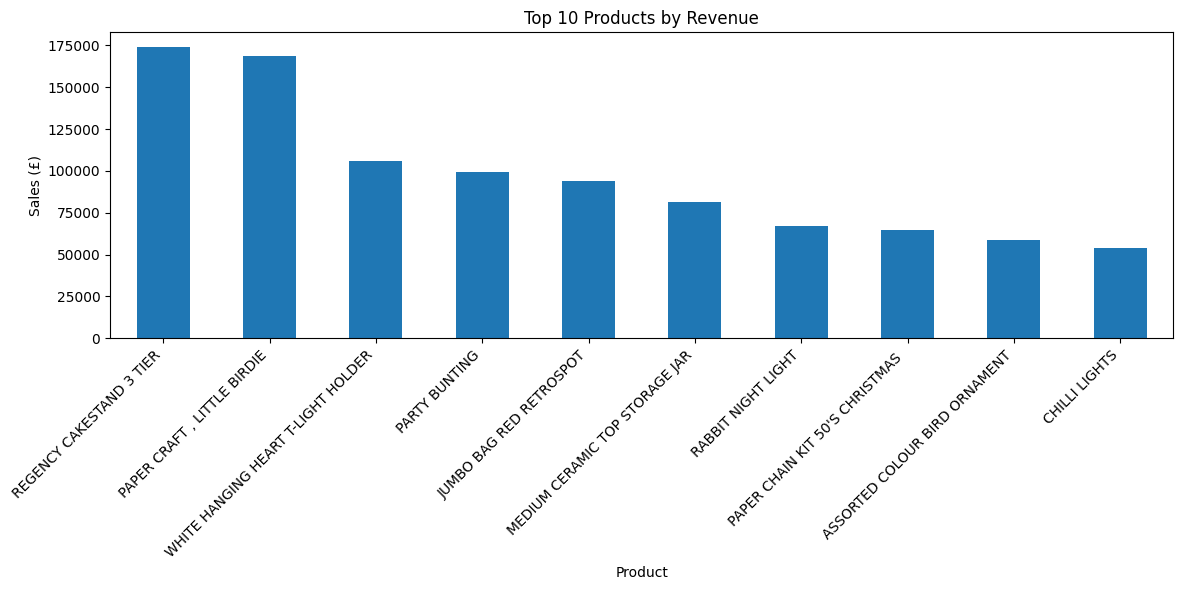

In [138]:
top_10_products = actual_product_sales.head(10)

top_10_products.plot(
    kind='bar',
    figsize=(12, 6),
    title='Top 10 Products by Revenue'
)

plt.xlabel('Product')
plt.ylabel('Sales (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Extract Month from Invoice Date

Create a new **Month** column by extracting the year and month from the **InvoiceDate** column for monthly sales analysis.

In [139]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

### Calculate Monthly Sales

Group the transactions by **Month** and calculate the total sales for each month.

In [140]:
monthly_sales = df.groupby('Month')['Sales'].sum()

In [141]:
monthly_sales

,Sales
Month,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,769296.610
2011-06,760547.010
2011-07,718076.121
2011-08,757841.380


### Visualize Monthly Sales Trend

Create a line chart to visualize how total sales change over time on a monthly basis.

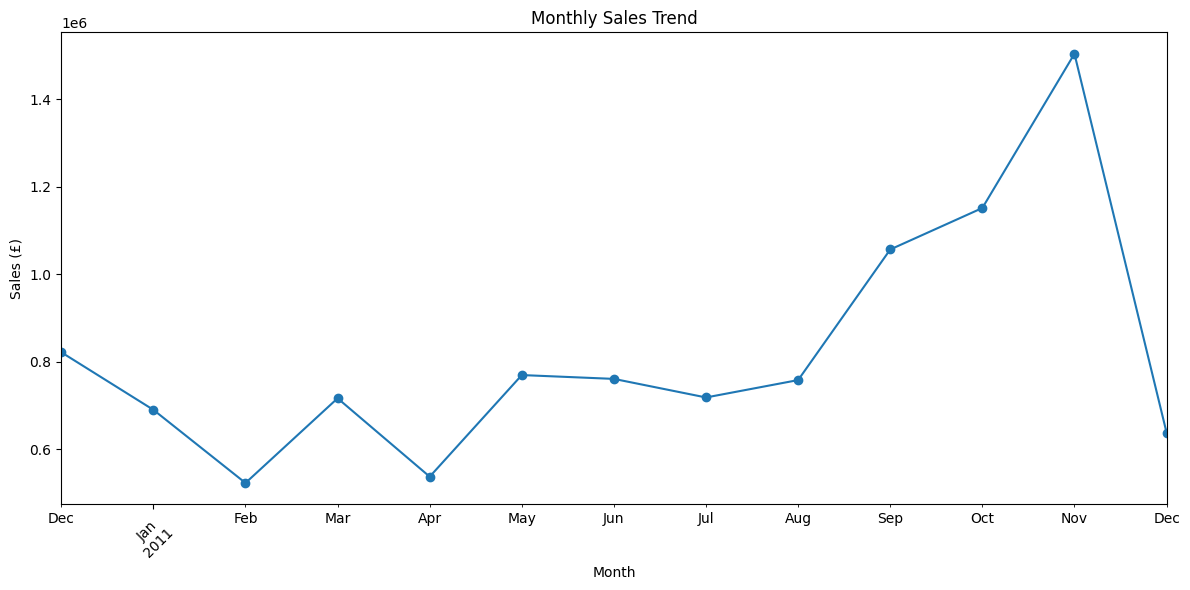

In [142]:
monthly_sales.plot(
    kind='line',
    figsize=(12, 6),
    marker='o',
    title='Monthly Sales Trend'
)

plt.xlabel('Month')
plt.ylabel('Sales (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Calculate Sales by Country

Group the transactions by **Country** and calculate the total sales for each country. Sort the results in descending order to identify the countries with the highest sales.

In [143]:
country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)

### Top 10 Countries by Sales

Display the top 10 countries with the highest total sales.

In [144]:
country_sales.head(10)

,Sales
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


### Visualize Top 10 Countries by Revenue

Create a bar chart to visualize the top 10 countries with the highest total sales.

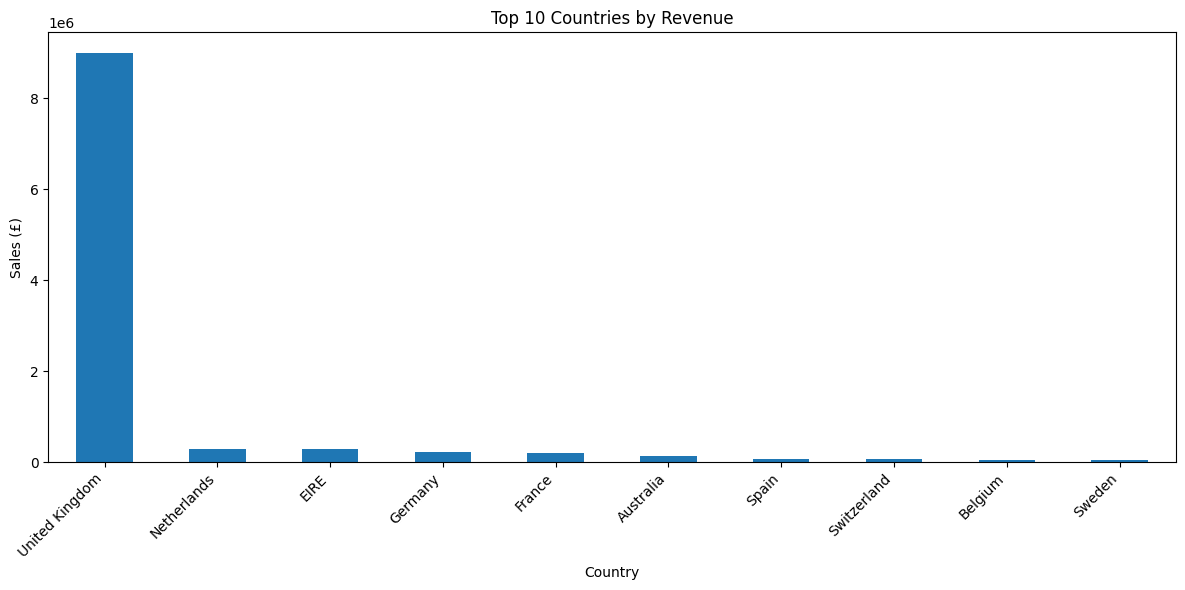

In [145]:
top_10_countries = country_sales.head(10)

top_10_countries.plot(
    kind='bar',
    figsize=(12, 6),
    title='Top 10 Countries by Revenue'
)

plt.xlabel('Country')
plt.ylabel('Sales (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Create Customer-Level Dataset

Create a separate dataset containing only transactions with a valid **CustomerID** for customer-level analysis.

In [146]:
customer_df = df.dropna(subset=['CustomerID']).copy()

### Customer Dataset Shape

Check the number of rows and columns in the customer-level dataset.

In [147]:
customer_df.shape

(392692, 10)

### Calculate Sales by Customer

Group transactions by **CustomerID** and calculate the total sales for each customer.

In [148]:
customer_sales = customer_df.groupby('CustomerID')['Sales'].sum().sort_values(ascending=False)

### Top 10 Customers by Sales

Display the top 10 customers with the highest total sales.

In [149]:
customer_sales.head(10)

,Sales
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


### Visualize Top 10 Customers by Revenue

Create a bar chart to visualize the top 10 customers with the highest total sales.

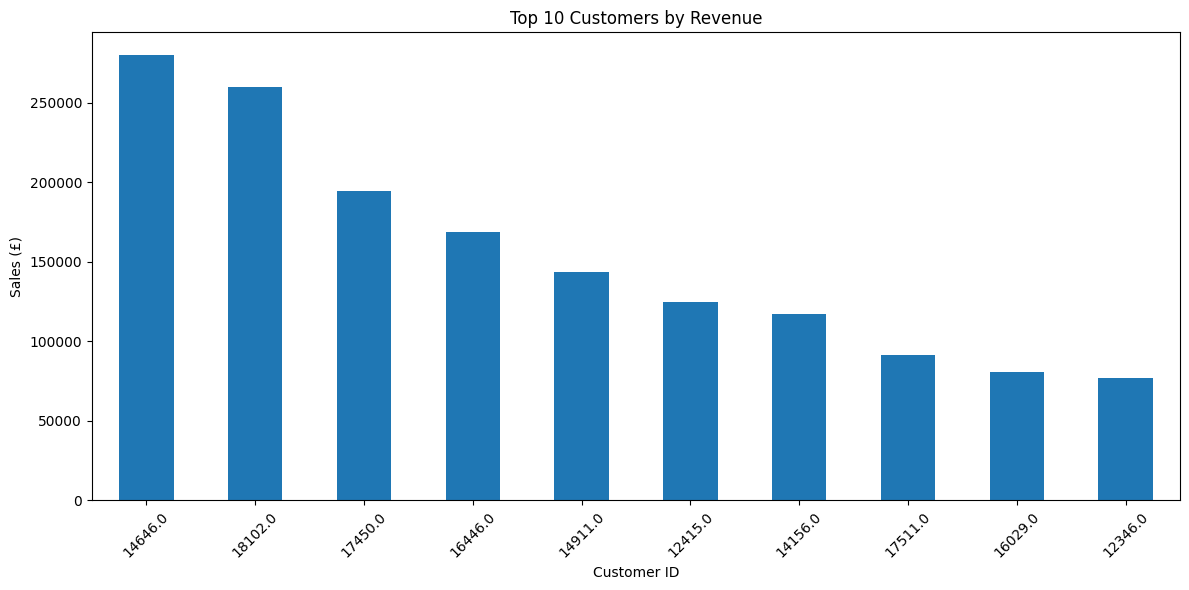

In [150]:
top_10_customers = customer_sales.head(10)

top_10_customers.plot(
    kind='bar',
    figsize=(12, 6),
    title='Top 10 Customers by Revenue'
)

plt.xlabel('Customer ID')
plt.ylabel('Sales (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Calculate Average Order Value

Calculate the **Average Order Value (AOV)** by finding the total sales for each invoice and then calculating the average across all invoices.

In [151]:
average_order_value = df.groupby('InvoiceNo')['Sales'].sum().mean()
average_order_value

np.float64(533.1718839679359)

### Calculate Unique Customers

Count the number of unique customers using the **CustomerID** column.

In [152]:
unique_customers = customer_df['CustomerID'].nunique()
unique_customers

4338

### Calculate Customer Purchase Frequency

Calculate how many unique invoices each customer has made to measure their purchase frequency.

In [153]:
customer_frequency = customer_df.groupby('CustomerID')['InvoiceNo'].nunique()


### Top 10 Most Frequent Customers

Display the top 10 customers with the highest number of unique purchases.

In [154]:
customer_frequency.sort_values(ascending=False).head(10)

,InvoiceNo
CustomerID,
12748.0,209
14911.0,201
17841.0,124
13089.0,97
14606.0,93
15311.0,91
12971.0,86
14646.0,73
16029.0,63


### Calculate Repeat Customers

Count the number of customers who made more than one purchase.

In [155]:
repeat_customers = (customer_frequency > 1).sum()
repeat_customers

np.int64(2845)

### Calculate Repeat Customer Rate

Calculate the percentage of customers who made more than one purchase.

In [156]:
repeat_customer_rate = (repeat_customers / unique_customers) * 100
repeat_customer_rate

np.float64(65.58321807284463)

### Segment Customers by Purchase Frequency

Classify customers into **Repeat Customer** or **One-time Customer** based on their number of unique purchases.

In [157]:
customer_segment = customer_frequency.apply(
    lambda x: 'Repeat Customer' if x > 1 else 'One-time Customer'
)

### Count Customer Segments

Count the number of customers in each segment: **Repeat Customer** and **One-time Customer**.

In [158]:
customer_segment.value_counts()

,count
InvoiceNo,
Repeat Customer,2845
One-time Customer,1493


### Visualize Customer Segmentation

Create a bar chart to compare the number of **Repeat Customers** and **One-time Customers**.

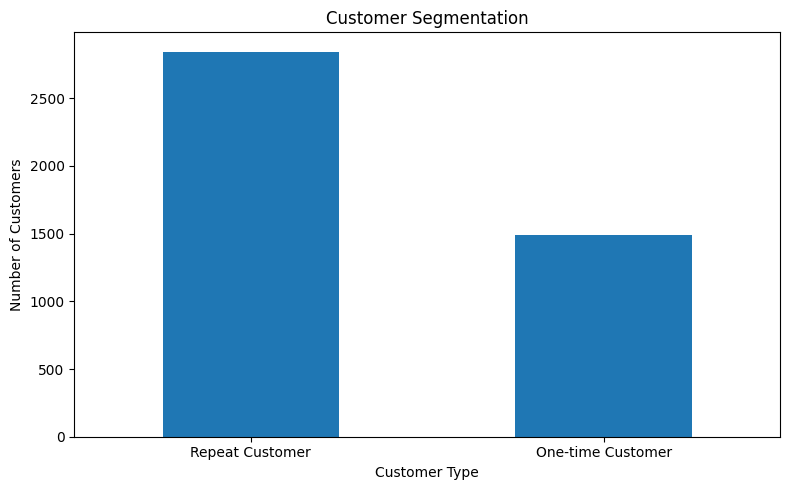

In [159]:
customer_segment.value_counts().plot(
    kind='bar',
    figsize=(8, 5),
    title='Customer Segmentation'
)

plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Key Performance Indicators

This section summarizes the key performance metrics from the sales analysis.

In [160]:
print("Total Sales:", total_sales)
print("Average Order Value:", average_order_value)
print("Unique Customers:", unique_customers)
print("Repeat Customers:", repeat_customers)
print("Repeat Customer Rate:", repeat_customer_rate)

Total Sales: 10642110.804
Average Order Value: 533.1718839679359
Unique Customers: 4338
Repeat Customers: 2845
Repeat Customer Rate: 65.58321807284463


In [161]:
top_product = actual_product_sales.index[0]
top_product_sales = actual_product_sales.iloc[0]

top_country = country_sales.index[0]
top_country_sales = country_sales.iloc[0]

print("Top Product:", top_product)
print("Top Product Sales:", top_product_sales)
print("Top Country:", top_country)
print("Top Country Sales:", top_country_sales)

Top Product: REGENCY CAKESTAND 3 TIER
Top Product Sales: 174156.54
Top Country: United Kingdom
Top Country Sales: 9001744.094


## Business Insights

1. The business generated total sales of approximately **£10.64 million**, indicating strong overall sales performance.

2. The average order value was approximately **£533.17**, meaning each invoice generated an average revenue of around £533.

3. The analysis identified **4,338 unique customers**, showing a substantial customer base.

4. **2,845 customers were repeat customers**, resulting in a repeat customer rate of approximately **65.58%**. This indicates strong customer retention and repeat purchasing behavior.

5. **REGENCY CAKESTAND 3 TIER** was the top-selling product by revenue, generating approximately **£174,156.54** in sales.

6. The **United Kingdom** was the highest-performing country, generating approximately **£9.00 million** in sales and representing the company's dominant sales market.

7. The strong repeat customer rate suggests that customer retention is an important strength of the business, while the high concentration of sales in the United Kingdom indicates an opportunity to explore growth in other markets.
8. Approximately **84.6% of total sales came from the United Kingdom**, indicating a high dependency on the UK market.

## Conclusion

This project analyzed transactional sales data to understand overall sales performance, product performance, customer purchasing behavior, and geographical sales distribution.

The analysis found total sales of approximately **£10.64 million**, with an average order value of **£533.17** across **4,338 unique customers**. The repeat customer rate of **65.58%** indicates strong customer retention. REGENCY CAKESTAND 3 TIER was the top-performing product by revenue, while the United Kingdom was the dominant sales market.

Overall, the analysis provides useful insights into product performance, customer behavior, and market concentration that can support future business decision-making.